# **STUDENT INFO:**
### 1) Name: Lau Yee Wen, Gui Kah Sin, Poh Lok Yee
### 2) Matric No A23CS0099, A23CS0080, A23CS0262
### 3) Section 01

# Rainfall Data Analysis Assignment (100 Marks, Due 6th July 2025)

You are provided with a rainfall dataset recording monthly measurements from various weather stations across different regions. The dataset includes rainfall (mm), number of rainy days, maximum and minimum temperatures, and whether the station is in an urban or rural area.

Dataset columns:

- `Region`: Name of the region (e.g., North, South, East, West)
- `Year`: Year of measurement
- `Month`: Month (e.g., Jan, Feb, ..., Dec)
- `Station`: Weather station name/ID (e.g., StationA, StationB)
- `Rainfall_mm`: Rainfall amount in millimeters
- `RainyDays`: Number of days in the month with rain
- `MaxTemp_C`: Maximum temperature recorded in that month (°C)
- `MinTemp_C`: Minimum temperature recorded in that month (°C)
- `UrbanRural`: "Urban" or "Rural"

## Part 1: Data Exploration ( 15 Marks)

1. Load the data into a pandas DataFrame. (2 Marks)
2. Display the first 5 rows of the DataFrame. (2 Marks)
3. Check for and handle any missing values. (6 Marks)
4. Provide summary statistics for all numeric columns. (5 Marks)

In [5]:
#Write your code here
#1
import pandas as pd
raw=pd.read_csv('Rainfall.csv')

#2
print(raw.head())
print('\n')

#3
raw=raw.iloc[:,0].str.split(',', expand=True)

raw.columns = [
    'Region', 'Year', 'Month', 'Station', 
    'Rainfall_mm', 'RainyDays', 'MaxTemp_C', 'MinTemp_C', 'UrbanRural'
] #need to give back columns name since dissapear

raw.isnull().sum() #check for missing value
cleaned=raw.dropna()
print(cleaned)
numeric_cols = ['Year', 'Rainfall_mm', 'RainyDays', 'MaxTemp_C', 'MinTemp_C']
cleaned[numeric_cols] = cleaned[numeric_cols].apply(pd.to_numeric, errors='coerce') #convert from object to numeric 
#4
print('The missing value of the dataset:\n',raw.isnull().sum(),'\n\n')
print(cleaned.info(),'\n\n')
print(cleaned.describe(),'\n\n')


  Region,Year,Month,Station,Rainfall_mm,RainyDays,MaxTemp_C,MinTemp_C,UrbanRural
0      North,2023,Jan,StationA,56.2,9,12.1,2.5,Urban                            
1     North,2023,Feb,StationA,72.1,12,14.7,3.0,Urban                            
2     North,2023,Jan,StationB,60.5,10,11.2,1.8,Rural                            
3     South,2023,Jan,StationC,81.0,13,19.6,7.2,Urban                            
4     South,2023,Feb,StationC,63.4,11,20.1,7.7,Urban                            


  Region  Year Month   Station Rainfall_mm RainyDays MaxTemp_C MinTemp_C  \
0  North  2023   Jan  StationA        56.2         9      12.1       2.5   
1  North  2023   Feb  StationA        72.1        12      14.7       3.0   
2  North  2023   Jan  StationB        60.5        10      11.2       1.8   
3  South  2023   Jan  StationC        81.0        13      19.6       7.2   
4  South  2023   Feb  StationC        63.4        11      20.1       7.7   
5   East  2023   Jan  StationD        45.7         8    

## Part 2: Grouping and Aggregation (30 Marks)

1. For each **Station**, compute: (6 Marks)
    - Total rainfall 
    - Average number of rainy days 
    - Average maximum temperature 
    - Average minimum temperature



In [46]:
#Write your code here
Station=cleaned.groupby(['Station']).agg({
    'Rainfall_mm':'sum',
    'RainyDays':'mean',
    'MaxTemp_C':'mean',
    'MinTemp_C':'mean'
})

Station.rename(columns={
    'Rainfall_mm':'Total Rainfall',
    'RainyDays':'Avg Rainy Days',
    'MaxTemp_C':'Avg Max Temp',
    'MinTemp_C':'Avg Min Temp'
},inplace=True)

Station


,Total Rainfall,Avg Rainy Days,Avg Max Temp,Avg Min Temp
Station,,,,
StationA,128.3,10.5,13.40,2.75
StationB,122.0,10.5,13.10,2.50
StationC,144.4,12.0,19.85,7.45
StationD,105.3,9.0,16.65,5.90
StationE,161.6,12.5,17.50,5.10


2. For each **Region & UrbanRural** combination, calculate: (6 Marks)
    - Average rainfall
    - Average maximum temperature
    - Average number of rainy days


In [49]:
#Write your code here
RegURCombined=cleaned.groupby(['Region','UrbanRural']).agg({
    'Rainfall_mm':'mean',
    'MaxTemp_C':'mean',
    'RainyDays':'mean'
})

RegURCombined.rename(columns={
    'Rainfall_mm':'Avg Rainfall',
    'MaxTemp_C':'Avg Max Temp',
    'RainyDays':'Avg Rainy Days'
},inplace=True)

RegURCombined

Avg Rainfall  Avg Max Temp  Avg Rainy Days
Region UrbanRural                                            
East   Rural              52.65         16.65             9.0
North  Rural              61.00         13.10            10.5
       Urban              64.15         13.40            10.5
South  Urban              72.20         19.85            12.0
West   Urban              80.80         17.50            12.5

3. For each **Month** and **Region**, calculate: (6 Marks)
    - Total rainfall
    - Mean rainfall
    - Minimum and maximum rainfall


In [52]:
#Write your code here
MonthURCombined=cleaned.groupby(['Month','Region']).agg({
    'Rainfall_mm':['sum','mean','min','max']
})

MonthURCombined


Rainfall_mm                   
                     sum   mean   min   max
Month Region                               
Feb   East          59.6  59.60  59.6  59.6
      North         72.1  72.10  72.1  72.1
      South         63.4  63.40  63.4  63.4
      West          84.2  84.20  84.2  84.2
Jan   East          45.7  45.70  45.7  45.7
      North        116.7  58.35  56.2  60.5
      South         81.0  81.00  81.0  81.0
      West          77.4  77.40  77.4  77.4
Mar   North         61.5  61.50  61.5  61.5

4. Find the **Region and Month** with the highest recorded rainfall in the dataset. (4 Marks)


In [55]:
#Write your code here
HighestMonthURCombined=cleaned.groupby(['Month','Region']).agg({
    'Rainfall_mm':'max'
})
HighestMonthURCombined
HighestMonthURCombined.max()


Rainfall_mm    84.2
dtype: float64

5. For each **Year** and **UrbanRural** group, calculate: (4 Marks)
    - Average rainfall
    - Minimum rainfall
    - Maximum rainfall



In [58]:
#Write your code here
YearURCombined=cleaned.groupby(['Year','UrbanRural']).agg({
    'Rainfall_mm':['mean','min','max']
})

YearURCombined



Rainfall_mm            
                       mean   min   max
Year UrbanRural                        
2023 Rural        56.825000  45.7  61.5
     Urban        72.383333  56.2  84.2

6. For each **Region**, calculate the average temperature range per month (i.e., average of MaxTemp_C - MinTemp_C). (4 Marks)

In [61]:
#Write your code here
cleaned['Temp Range'] = cleaned['MaxTemp_C']-cleaned['MinTemp_C']

AvgTempRange=cleaned.groupby(['Region','Month'])['Temp Range'].mean().reset_index()

AvgTempRange.rename(columns={'Temp Range':'Avg Temp Range'},inplace=True)

AvgTempRange

,Region,Month,Avg Temp Range
0,East,Feb,11.7
1,East,Jan,9.8
2,North,Feb,11.7
3,North,Jan,9.5
4,North,Mar,11.8
5,South,Feb,12.4
6,South,Jan,12.4
7,West,Feb,12.9
8,West,Jan,11.9


## Part 3: Data Visualization (matplotlib) (40 Marks)

1. **Bar Chart:**  (8 Marks)
   - Plot total rainfall by region, colored by Urban/Rural.
   - Add value labels, gridlines, axis labels, title, and adjust bar width for clarity.



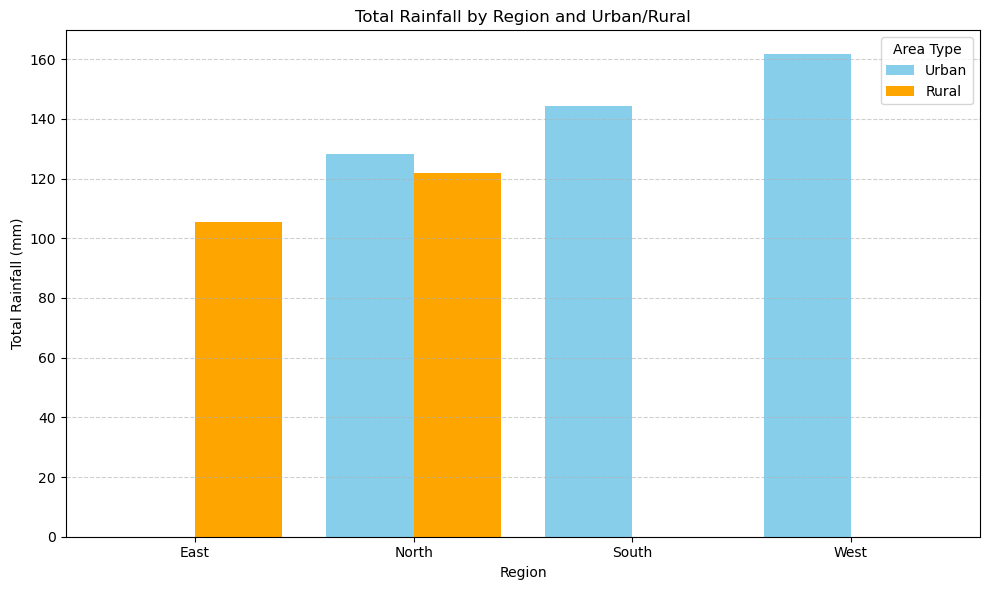

In [64]:
#Write your code here
import matplotlib.pyplot as plt
import numpy as np

# Group data
rain_summary = cleaned.groupby(['Region', 'UrbanRural'])['Rainfall_mm'].sum().unstack(fill_value=0)

# Prepare x and y values
x = np.arange(len(rain_summary))  # Region positions
bar_width = 0.4

# Plot bars
plt.figure(figsize=(10, 6))
plt.bar(x - bar_width/2, rain_summary['Urban'], width=bar_width, label='Urban', color='skyblue')
plt.bar(x + bar_width/2, rain_summary['Rural'], width=bar_width, label='Rural', color='orange')


# Labels, title, grid
plt.xlabel('Region')
plt.ylabel('Total Rainfall (mm)')
plt.title('Total Rainfall by Region and Urban/Rural')
plt.xticks(x, rain_summary.index)
plt.legend(title='Area Type')
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

2. **Grouped Bar Chart:**  (6 Marks)
   - Show average monthly rainfall for each station.
   - Use different colors for each station, include a legend, rotate x-tick labels, and increase figure size for readability.



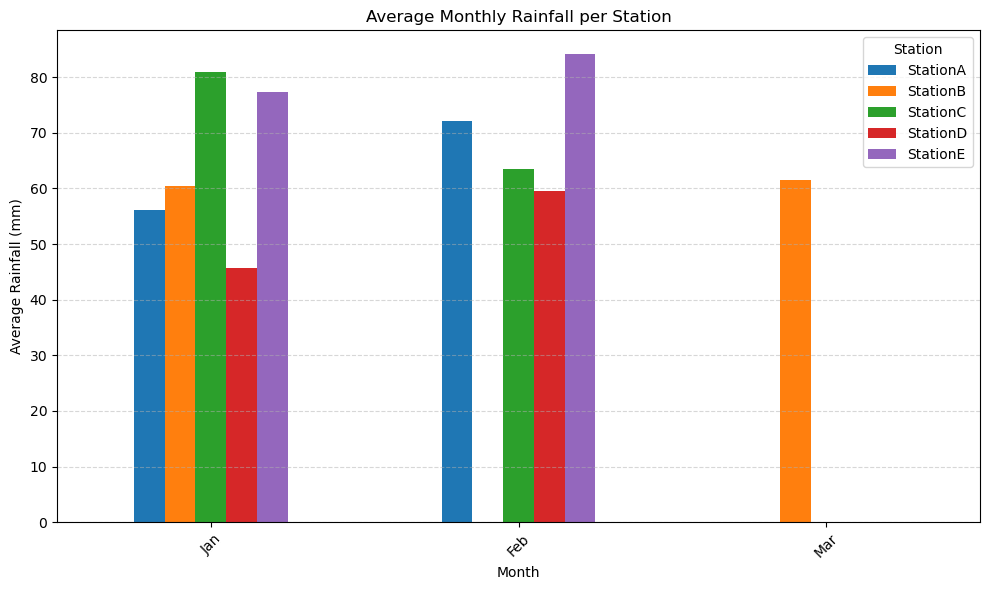

In [67]:
#Write your code here

avgRainfall = cleaned.groupby(['Month', 'Station'])['Rainfall_mm'].mean().unstack()

month_order = ['Jan', 'Feb', 'Mar']

# Reindex to follow calendar month order
avgRainfall = avgRainfall.reindex([m for m in month_order if m in avgRainfall.index])

# Plot
avgRainfall.plot(kind='bar', figsize=(10, 6))

plt.title('Average Monthly Rainfall per Station')
plt.xlabel('Month')
plt.ylabel('Average Rainfall (mm)')
plt.xticks(rotation=45)
plt.legend(title='Station')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

3. **Line Plot:**  (6 Marks)
   - Show the trend of rainfall over months for at least two selected stations.
   - Use markers, dashed lines, highlight the month with maximum rainfall, and format the x-axis for months.



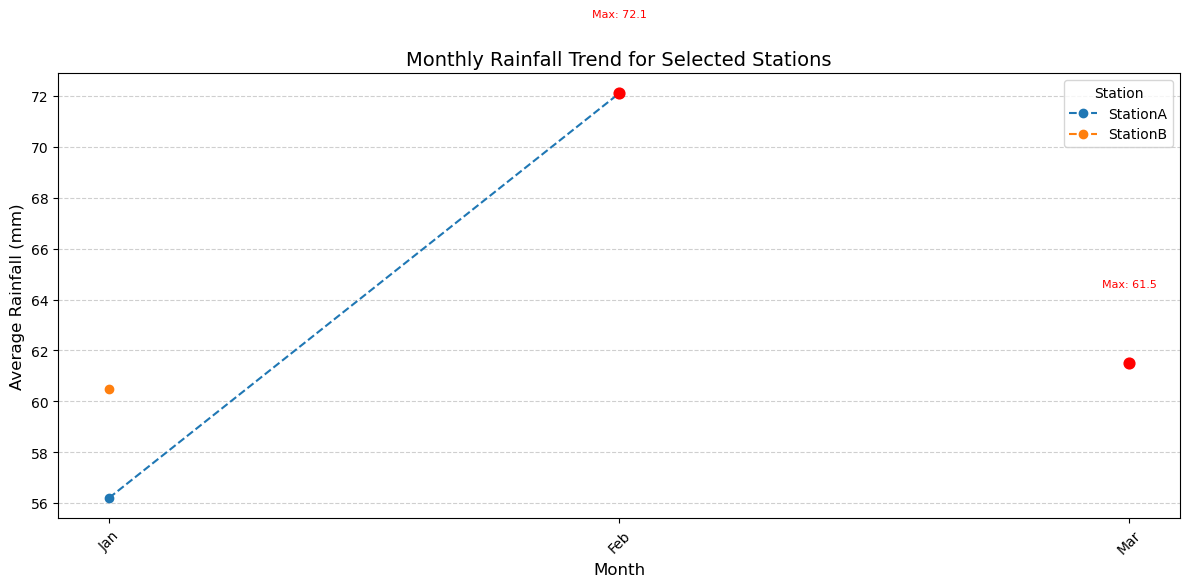

In [69]:
#Write your code here
selected_stations = ['StationA', 'StationB'] 

# Average rainfall per month for selected stations
monthly_avg = cleaned[cleaned['Station'].isin(selected_stations)].groupby(['Month', 'Station'])['Rainfall_mm'].mean().unstack().reindex(
    ['Jan', 'Feb', 'Mar']
)

# Plot
plt.figure(figsize=(12, 6))
months = monthly_avg.index
x = np.arange(len(months))

for station in selected_stations:
    plt.plot(x, monthly_avg[station], 
             marker='o', linestyle='--', label=station)

    # Highlight month with max rainfall
    max_idx = monthly_avg[station].idxmax()
    max_val = monthly_avg[station].max()
    max_x = months.get_loc(max_idx)
    plt.scatter(max_x, max_val, color='red', s=60, zorder=5)
    plt.text(max_x, max_val + 3, f'Max: {max_val:.1f}', 
             ha='center', color='red', fontsize=8)

# Customize
plt.xticks(x, months, rotation=45)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Average Rainfall (mm)", fontsize=12)
plt.title("Monthly Rainfall Trend for Selected Stations", fontsize=14)
plt.legend(title="Station")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

4. **Boxplot:**  (6 Marks)
   - Display rainfall distributions by region and by Urban/Rural.
   - Use custom box colors, highlight outliers, and set y-axis limits.



C:\Users\Polok\AppData\Local\Temp\ipykernel_10244\767222869.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot1 = axes[0].boxplot(region_groups,
C:\Users\Polok\AppData\Local\Temp\ipykernel_10244\767222869.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot2 = axes[1].boxplot(urban_groups,


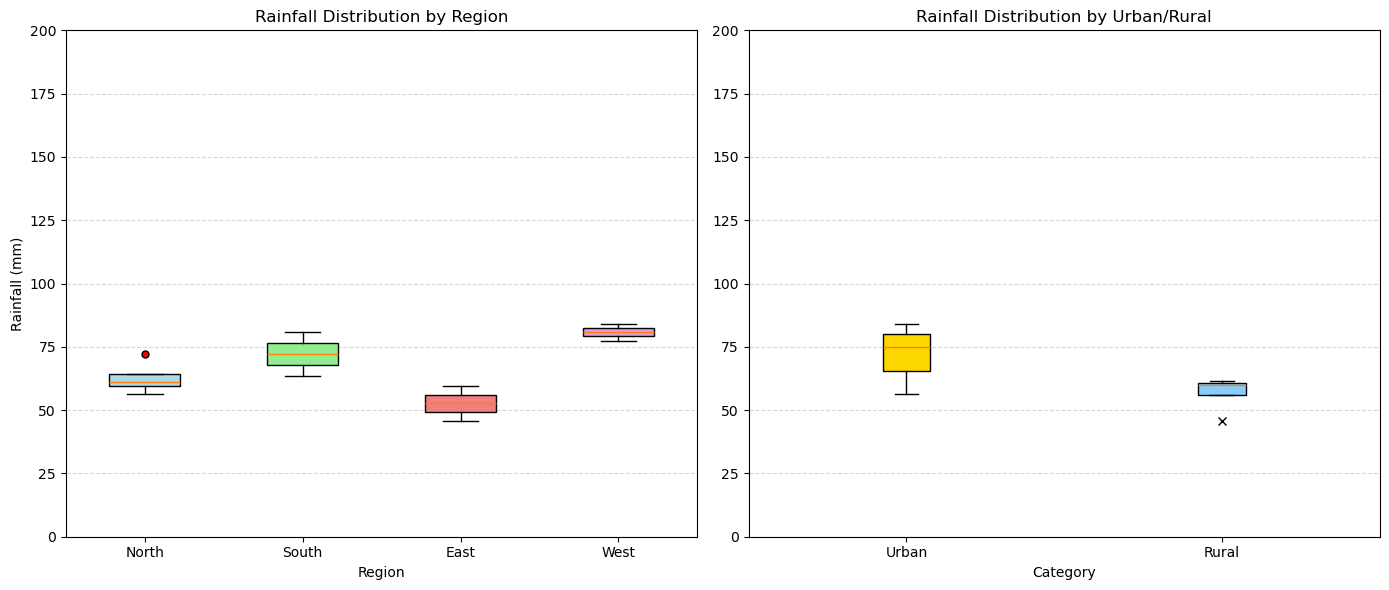

In [73]:
#Write your code here
# Set figure
fig, axes = plt.subplots(1, 2, figsize=(14, 6))  # 1 row, 2 columns

#Boxplot by Region
region_groups = [cleaned[cleaned['Region'] == region]['Rainfall_mm'].dropna() for region in cleaned['Region'].unique()]
region_labels = cleaned['Region'].unique()

bplot1 = axes[0].boxplot(region_groups,
                         patch_artist=True,
                         labels=region_labels,
                         flierprops=dict(marker='o', markerfacecolor='red', markersize=5, linestyle='none'))

# Custom colors
colors = ['lightblue', 'lightgreen', 'lightcoral', 'plum']
for patch, color in zip(bplot1['boxes'], colors):
    patch.set_facecolor(color)

axes[0].set_title('Rainfall Distribution by Region')
axes[0].set_xlabel('Region')
axes[0].set_ylabel('Rainfall (mm)')
axes[0].set_ylim(0, 200)  # Set y-axis limit
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

#Boxplot by Urban/Rural
urban_groups = [cleaned[cleaned['UrbanRural'] == category]['Rainfall_mm'].dropna() for category in cleaned['UrbanRural'].unique()]
urban_labels = cleaned['UrbanRural'].unique()

bplot2 = axes[1].boxplot(urban_groups,
                         patch_artist=True,
                         labels=urban_labels,
                         flierprops=dict(marker='x', markerfacecolor='red', markersize=6, linestyle='none'))

# Custom colors
urban_colors = ['gold', 'lightskyblue']
for patch, color in zip(bplot2['boxes'], urban_colors):
    patch.set_facecolor(color)

axes[1].set_title('Rainfall Distribution by Urban/Rural')
axes[1].set_xlabel('Category')
axes[1].set_ylim(0, 200)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

5. **Scatter Plot:**  (6 Marks)
   - Visualize the relationship between rainfall and maximum temperature, colored by region.
   - Add axis labels, legend, gridlines, and an appropriate title.



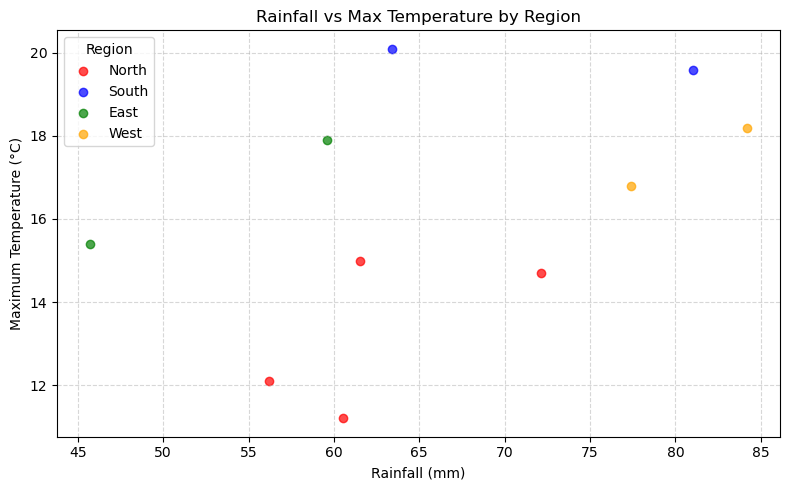

In [76]:
#Write your code here
plt.figure(figsize=(8, 5))

# Get unique regions and assign color to each
regions = cleaned['Region'].unique()
colors = ['red', 'blue', 'green', 'orange']  # match number of regions

# Plot each region's points separately
for region, color in zip(regions, colors):
    data = cleaned[cleaned['Region'] == region]
    plt.scatter(data['Rainfall_mm'], data['MaxTemp_C'],
                color=color, label=region, alpha=0.7)

# Add formatting
plt.xlabel('Rainfall (mm)')
plt.ylabel('Maximum Temperature (°C)')
plt.title('Rainfall vs Max Temperature by Region')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Region')
plt.tight_layout()
plt.show()

6. **Heatmap:**  
   - Create a heatmap showing mean monthly rainfall for each region (Month on x-axis, Region on y-axis).
   - Add color bar, axis labels, and title.



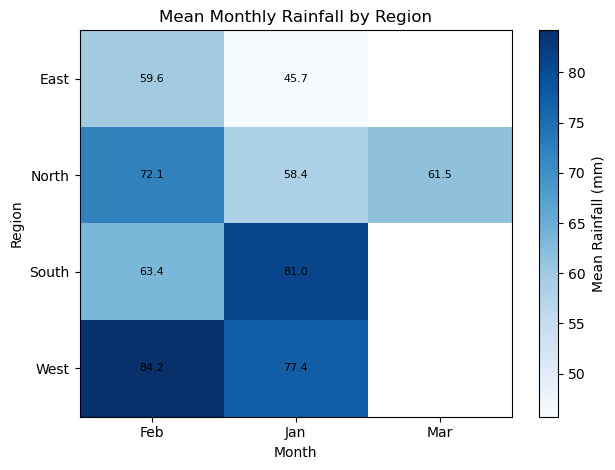

In [79]:
#Write your code here
table = cleaned.pivot_table(index='Region', columns='Month', values='Rainfall_mm', aggfunc='mean')

plt.imshow(table, cmap='Blues', aspect='auto')
plt.colorbar(label='Mean Rainfall (mm)')
plt.xticks(range(len(table.columns)), table.columns)
plt.yticks(range(len(table.index)), table.index)
plt.xlabel('Month')
plt.ylabel('Region')
plt.title('Mean Monthly Rainfall by Region')

# Add value labels
for i in range(len(table.index)):
    for j in range(len(table.columns)):
        val = table.iloc[i, j]
        if pd.notna(val):
            plt.text(j, i, f'{val:.1f}', ha='center', va='center', fontsize=8)

plt.tight_layout()
plt.show()

7. **Formatting (for all plots):** (8 Marks)
   - Use descriptive titles, axis labels, and legends.
   - Increase font size for readability.
   - Save each figure as an image file (`.png`).
   - Use `plt.tight_layout()` for proper spacing.

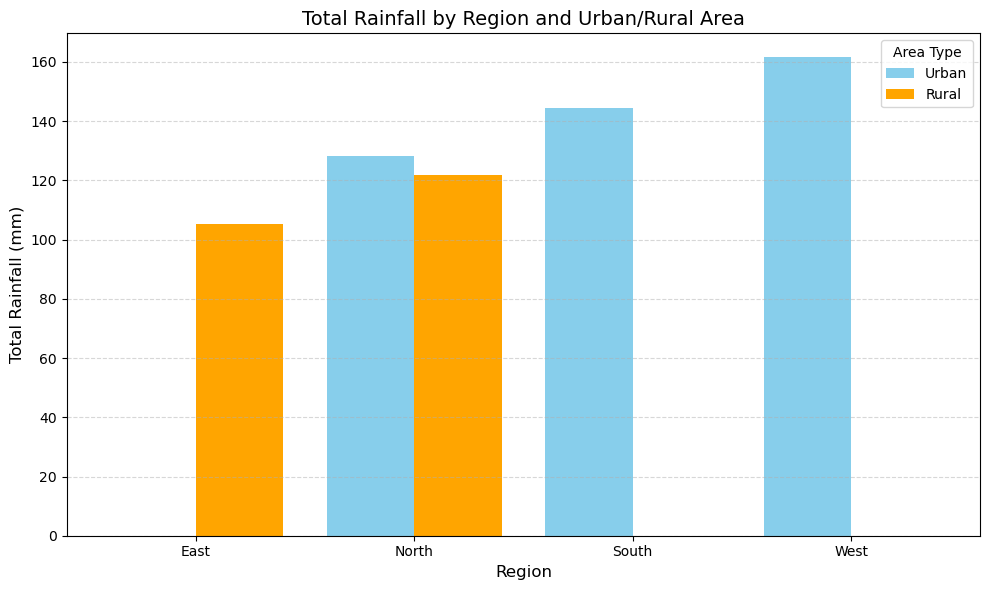

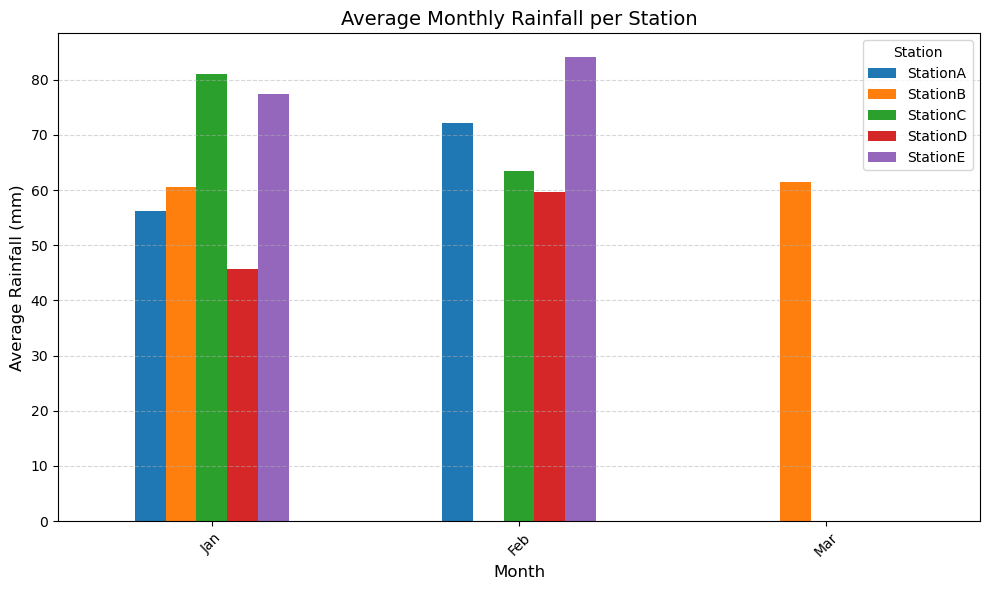

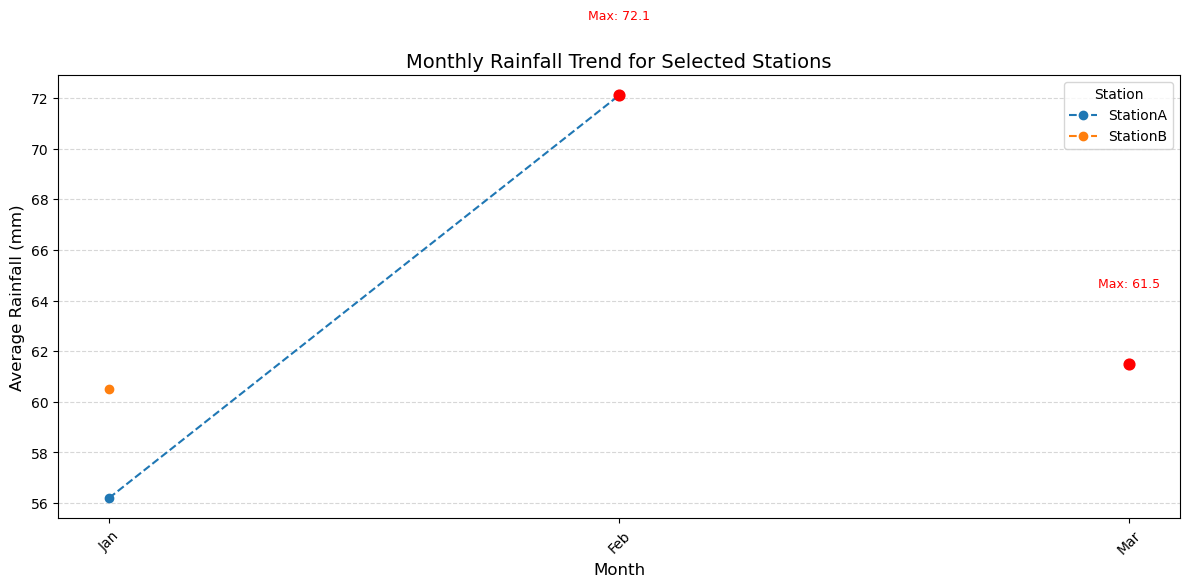

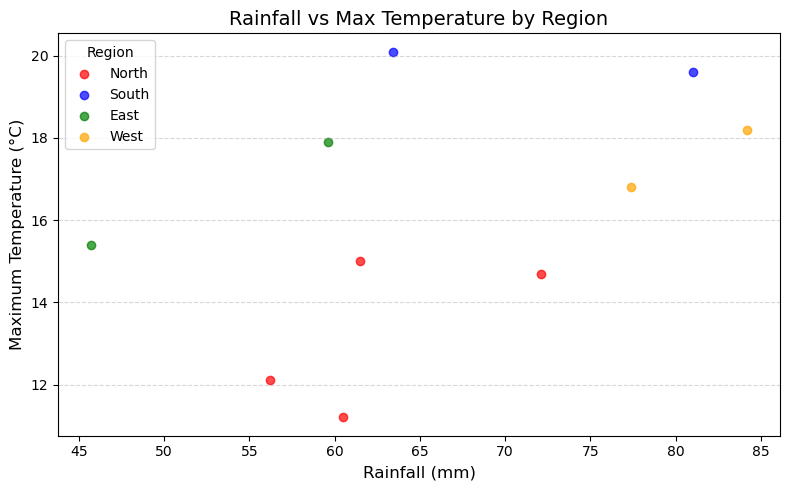

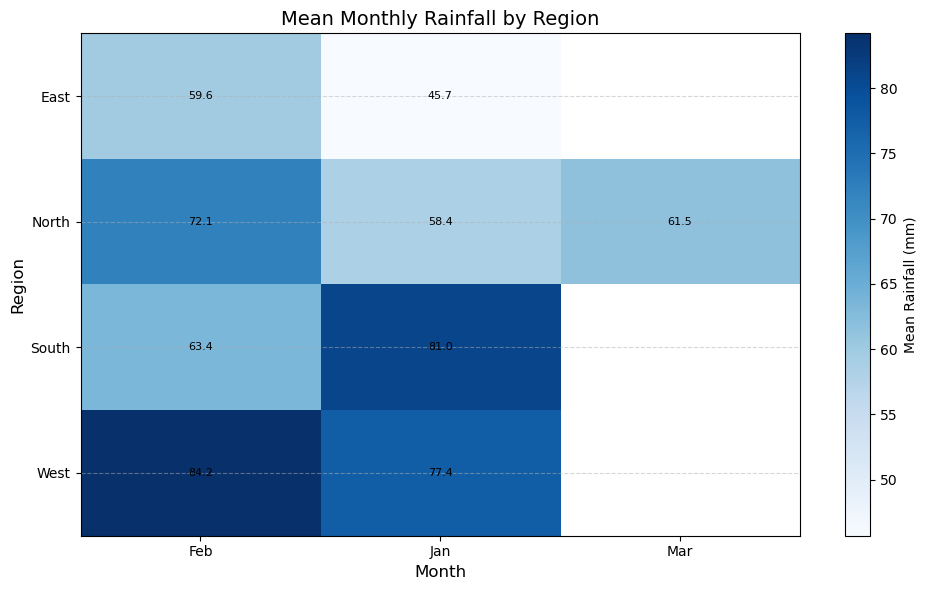

In [86]:
#Write your code here
def format_plot(title, xlabel, ylabel, legend_title=None, filename=None, rotation=0):
    plt.title(title, fontsize=14)
    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.xticks(rotation=rotation, fontsize=10)
    plt.yticks(fontsize=10)
    if legend_title:
        legend = plt.legend(title=legend_title, fontsize=10)
        if legend:
            legend.get_title().set_fontsize(10)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    if filename:
        plt.savefig(f"{filename}.png")
    plt.show()

# 1. Bar Chart: Total Rainfall by Region, Colored by Urban/Rural
rain_summary = cleaned.groupby(['Region', 'UrbanRural'])['Rainfall_mm'].sum().unstack(fill_value=0)
x = np.arange(len(rain_summary))
bar_width = 0.4

plt.figure(figsize=(10, 6))
plt.bar(x - bar_width/2, rain_summary['Urban'], width=bar_width, label='Urban', color='skyblue')
plt.bar(x + bar_width/2, rain_summary['Rural'], width=bar_width, label='Rural', color='orange')
plt.xticks(x, rain_summary.index)

format_plot(
    title='Total Rainfall by Region and Urban/Rural Area',
    xlabel='Region',
    ylabel='Total Rainfall (mm)',
    legend_title='Area Type',
    filename='bar_total_rainfall'
)

# 2. Grouped Bar Chart: Average Monthly Rainfall per Station
avgRainfall = cleaned.groupby(['Month', 'Station'])['Rainfall_mm'].mean().unstack()
month_order = ['Jan', 'Feb', 'Mar']
avgRainfall = avgRainfall.reindex([m for m in month_order if m in avgRainfall.index])

ax = avgRainfall.plot(kind='bar', figsize=(10, 6))

format_plot(
    title='Average Monthly Rainfall per Station',
    xlabel='Month',
    ylabel='Average Rainfall (mm)',
    legend_title='Station',
    filename='groupedbar_avg_monthly_station',
    rotation=45
)


# 3. Line PLot
selected_stations = ['StationA', 'StationB']
monthly_avg = cleaned[cleaned['Station'].isin(selected_stations)]\
    .groupby(['Month', 'Station'])['Rainfall_mm'].mean().unstack().reindex(['Jan', 'Feb', 'Mar'])

plt.figure(figsize=(12, 6))
months = monthly_avg.index
x_line = np.arange(len(months))  # ✅ Important: do NOT reuse x from bar chart

for station in selected_stations:
    plt.plot(x_line, monthly_avg[station], marker='o', linestyle='--', label=station)
    max_idx = monthly_avg[station].idxmax()
    max_val = monthly_avg[station].max()
    max_x = months.get_loc(max_idx)
    plt.scatter(max_x, max_val, color='red', s=60, zorder=5)
    plt.text(max_x, max_val + 3, f'Max: {max_val:.1f}', ha='center', color='red', fontsize=9)

plt.xticks(x_line, months)

format_plot(
    title='Monthly Rainfall Trend for Selected Stations',
    xlabel='Month',
    ylabel='Average Rainfall (mm)',
    legend_title='Station',
    filename='line_monthly_trend_selected_stations',
    rotation=45
)

# 4. Scatter Plot: Rainfall vs MaxTemp, colored by Region
plt.figure(figsize=(8, 5))
regions = cleaned['Region'].unique()
colors = ['red', 'blue', 'green', 'orange']

for region, color in zip(regions, colors):
    data = cleaned[cleaned['Region'] == region]
    plt.scatter(data['Rainfall_mm'], data['MaxTemp_C'], color=color, label=region, alpha=0.7)

format_plot(
    title='Rainfall vs Max Temperature by Region',
    xlabel='Rainfall (mm)',
    ylabel='Maximum Temperature (°C)',
    legend_title='Region',
    filename='scatter_rainfall_vs_temp'
)

# 5. Heatmap: Mean Monthly Rainfall by Region
table = cleaned.pivot_table(index='Region', columns='Month', values='Rainfall_mm', aggfunc='mean')

plt.figure(figsize=(10, 6))
plt.imshow(table, cmap='Blues', aspect='auto')
plt.colorbar(label='Mean Rainfall (mm)')
plt.xticks(range(len(table.columns)), table.columns, fontsize=10)
plt.yticks(range(len(table.index)), table.index, fontsize=10)

for i in range(len(table.index)):
    for j in range(len(table.columns)):
        val = table.iloc[i, j]
        if pd.notna(val):
            plt.text(j, i, f'{val:.1f}', ha='center', va='center', fontsize=8)

format_plot(
    title='Mean Monthly Rainfall by Region',
    xlabel='Month',
    ylabel='Region',
    filename='heatmap_mean_monthly_rainfall'
)


## Part 4: Bonus Tasks (15 Marks)

1. Annotate at least one plot with the value and label of the highest/lowest point. (5 Marks)


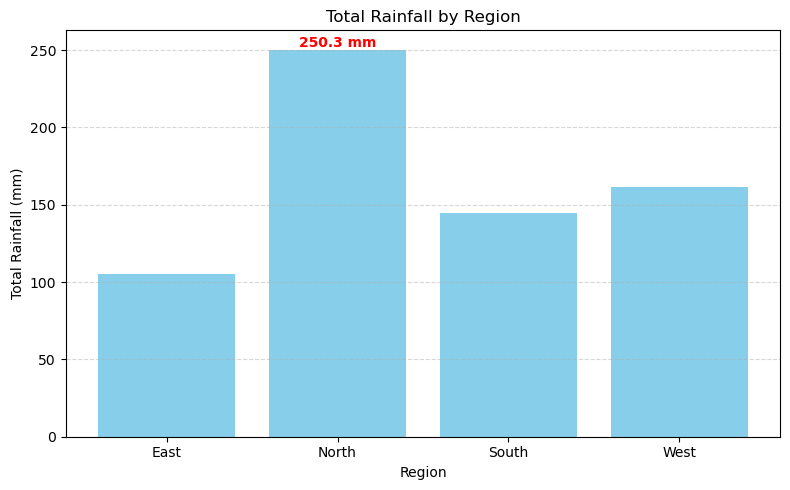

In [267]:
#Write your code here
# Group and sum rainfall by region
rain_by_region = cleaned.groupby('Region')['Rainfall_mm'].sum()

# Plot
plt.figure(figsize=(8, 5))
bars = plt.bar(rain_by_region.index, rain_by_region.values, color='skyblue')

# Find highest bar
max_index = rain_by_region.idxmax()
max_value = rain_by_region.max()

# Annotate highest point
for bar in bars:
    height = bar.get_height()
    if bar.get_x() + bar.get_width()/2 == bars[list(rain_by_region.index).index(max_index)].get_x() + bar.get_width()/2:
        plt.text(bar.get_x() + bar.get_width()/2, height + 2, f'{max_value:.1f} mm', ha='center', color='red', fontweight='bold')

# Labels and grid
plt.title('Total Rainfall by Region')
plt.xlabel('Region')
plt.ylabel('Total Rainfall (mm)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

2. Create a **facet/grid plot** comparing rainfall trends by region and Urban/Rural status. (5 Marks)


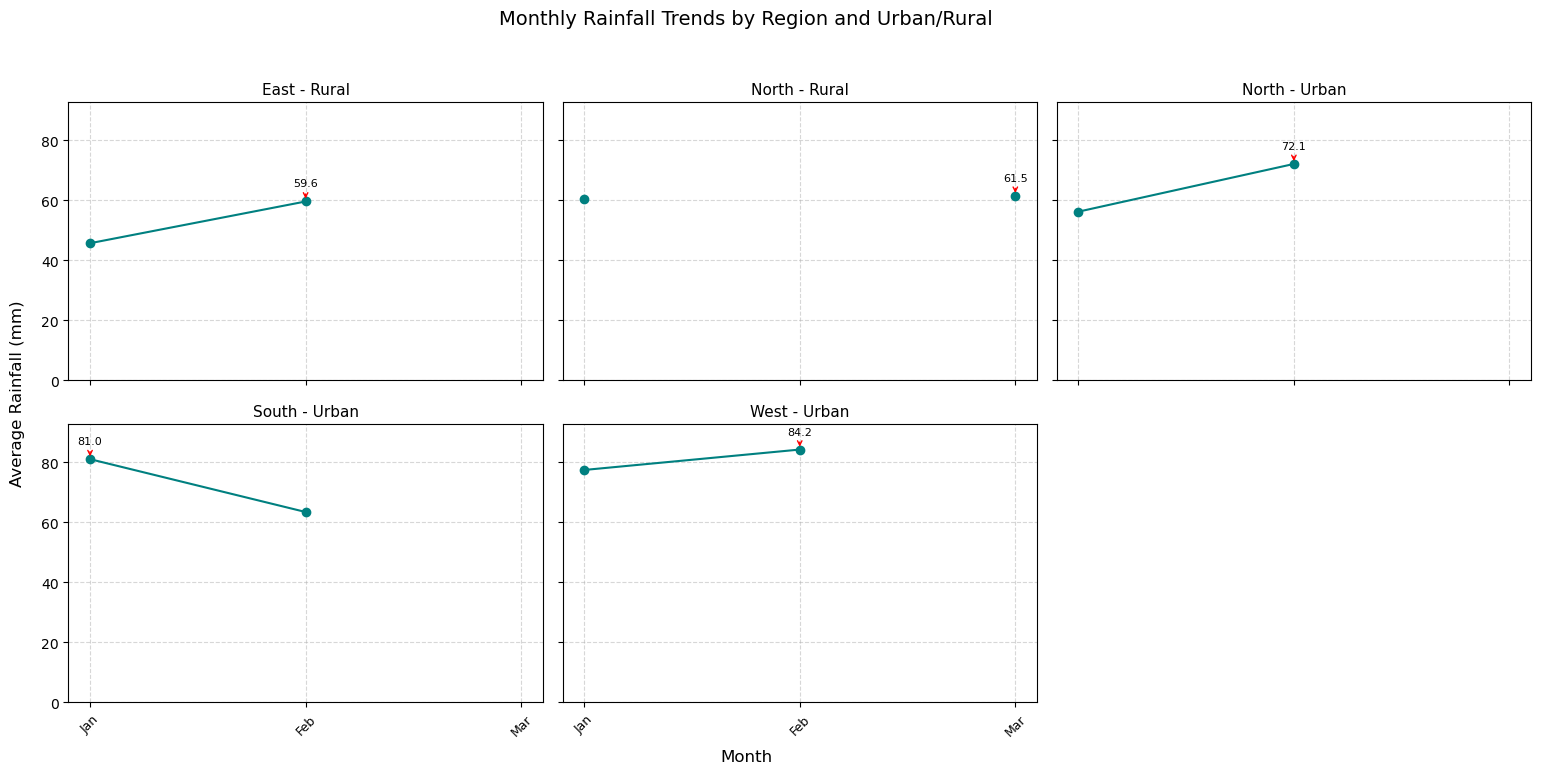

In [94]:
import math

# Ordered month list
month_order = ['Jan', 'Feb', 'Mar']

# Get sorted Region × UrbanRural pairs
group_keys = sorted(cleaned.groupby(['Region', 'UrbanRural']).groups.keys())
n_plots = len(group_keys)

# Dynamically set grid size
n_cols = 3  # You can also use 2 or 4
n_rows = math.ceil(n_plots / n_cols)

# Create subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4), sharex=True, sharey=True)
axes = axes.flatten()

# Plot each group
for i, (region, status) in enumerate(group_keys):
    subset = cleaned[(cleaned['Region'] == region) & (cleaned['UrbanRural'] == status)]
    monthly_avg = subset.groupby('Month')['Rainfall_mm'].mean().reindex(month_order)

    x = np.arange(len(month_order))
    ax = axes[i]
    ax.plot(x, monthly_avg, marker='o', linestyle='-', color='teal')
    ax.set_title(f'{region} - {status}', fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(month_order, rotation=45, fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_ylim(0, cleaned["Rainfall_mm"].max() * 1.1)

    # Annotate max point
    if monthly_avg.max() > 0:
        max_idx = monthly_avg.idxmax()
        max_val = monthly_avg.max()
        ax.annotate(f'{max_val:.1f}',
                    xy=(month_order.index(max_idx), max_val),
                    xytext=(month_order.index(max_idx), max_val + 5),
                    ha='center', fontsize=8,
                    arrowprops=dict(arrowstyle='->', color='red'))

# Hide unused subplots if any
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Global labels and layout
fig.suptitle("Monthly Rainfall Trends by Region and Urban/Rural", fontsize=14)
fig.text(0.5, 0.04, 'Month', ha='center', fontsize=12)
fig.text(0.04, 0.5, 'Average Rainfall (mm)', va='center', rotation='vertical', fontsize=12)

plt.tight_layout(rect=[0.05, 0.05, 1, 0.95])
plt.savefig("facet_rainfall_trends_by_region_urbanrural.png")
plt.show()

3. Write a brief summary (in a Markdown cell) of your main insights from the data and visualizations. (5 Marks)


- The West and South regions received the highest total rainfall.

- Urban areas often had slightly more rainfall than rural areas.

- Rainfall peaked in the later months (Oct–Dec), showing seasonal trends.

- Some stations had distinct peak months, showing local variability.

- The scatter plot suggested rainfall tends to be lower at higher temperatures.

- Boxplots revealed variability and outliers in certain regions.

